# Reprezentatywność -- miary i przykłady

**Autor:** Maciej Beręsewicz

## Pakiety

In [1]:
## pip install pandas numpy matplotlib scipy statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

# Data Defect Index (Meng 2018)

## Tożsamość Menga

Błąd estymacji ze źródła danych o liczebności $n$ z populacji o liczebności $N$ można rozłożyć na trzy składniki:

$$
\overline{G}_{n}-\overline{G}_{N}=\underbrace{\rho_{R, G}}_{\text{Jakość danych}} \times \underbrace{\sqrt{\frac{1-f}{f}}}_{\text{Ilość danych}} \times \underbrace{\sigma_{G}}_{\text{Złożoność problemu}},
$$

gdzie:

- $\rho_{R,G} = \text{Corr}(R_j, G_j)$ -- korelacja między zmienną indykatorową włączenia do próby $R$ a wartościami cechy $G$ (**data defect correlation**; ddc),
- $f = n/N$ -- odsetek w próbie,
- $\sigma_G$ -- odchylenie standardowe cechy $G$ w populacji.

**Data defect index** (ddi) to $\rho_{R,G}^2$.

## Funkcja DDC

In [3]:
def ddc(mu, muhat, N, n):
    """Data Defect Correlation (Meng 2018)."""
    f = n / N
    sigma_G = np.sqrt(mu * (1 - mu))  ## dla proporcji
    rho = (muhat - mu) / (sigma_G * np.sqrt((1 - f) / f))
    return rho

## Wybory w USA 2016

Zbiór danych `g2016` z pakietu R `ddi` -- wyniki wyborów prezydenckich 2016. Dane porównują oficjalne wyniki z szacunkami z *Cooperative Congressional Election Study* (CCES) -- dużego badania ankietowego ($n \approx 65$ tys.).

Wczytujemy dane z CSV (wyeksportowane z R).

In [4]:
## wczytanie danych -- wyeksportowane z R: write.csv(ddi::g2016, "g2016.csv", row.names=FALSE)
## alternatywnie: https://raw.githubusercontent.com/kuriwaki/ddi/master/data-raw/g2016.csv
try:
    g2016 = pd.read_csv("../data/g2016.csv")
except FileNotFoundError:
    ## jeśli brak lokalnego pliku, tworzymy z danych wbudowanych
    print("Plik g2016.csv nie znaleziony. Proszę wyeksportować z R:")
    print('  library(ddi); write.csv(g2016, "codes/data/g2016.csv", row.names=FALSE)')
    raise

### Opis kolumn

| Kolumna | Opis |
|---------|------|
| `state`, `st` | Nazwa stanu (pełna i skrót) |
| `pct_djt_voters` | Oficjalny odsetek głosów na Trumpa (populacja, $\mu$) |
| `cces_pct_djt_vv` | Odsetek głosów na Trumpa w CCES wśród zweryfikowanych wyborców (próba, $\hat{\mu}$) |
| `votes_djt` | Łączna liczba głosów na Trumpa |
| `tot_votes` | Frekwencja -- łączna liczba oddanych głosów ($N$) |
| `cces_totdjt_vv` | Liczba zweryfikowanych wyborców Trumpa w CCES |
| `cces_n_vv` | Liczba zweryfikowanych wyborców w próbie CCES ($n$) |
| `vap` | Populacja w wieku wyborczym (*Voting Age Population*) |
| `vep` | Populacja uprawniona do głosowania (*Voting Eligible Population*) |

In [5]:
g2016[["st", "pct_djt_voters", "cces_pct_djt_vv", "tot_votes", "cces_n_vv"]].head()

,st,pct_djt_voters,cces_pct_djt_vv,tot_votes,cces_n_vv
0,AL,0.620831,0.407692,2123372,390
1,AK,0.512815,0.305556,318608,72
2,AZ,0.486716,0.423208,2573165,879
3,AR,0.605741,0.416370,1130635,281
4,CA,0.316171,0.285397,14181595,3150


### DDC dla całego USA

In [6]:
rho = ddc(
    mu    = 62984824 / 136639786,
    muhat = 12284 / 35829,
    N     = 136639786,
    n     = 35829
)
print(f"ddc: {rho:.6f}")
print(f"ddi: {rho**2:.2e}")

ddc: -0.003837
ddi: 1.47e-05


Interpretacja:

- **DDC** $\hat{\rho} \approx -0.004$ -- ujemna korelacja oznacza, że wyborcy Trumpa byli **niedoreprezentowani** w CCES (osoby głosujące na Trumpa miały niższe prawdopodobieństwo udziału w badaniu).
- **DDI** $\approx 1.5 \times 10^{-5}$ -- choć wygląda na znikomą wartość, przy populacji $N \approx 137$ mln nawet tak mała korelacja generuje istotny błąd.

### DDC dla każdego stanu

In [7]:
g2016["ddc"] = ddc(
    mu    = g2016["pct_djt_voters"].values,
    muhat = g2016["cces_pct_djt_vv"].values,
    N     = g2016["tot_votes"].values,
    n     = g2016["cces_n_vv"].values
)
g2016["blad"] = g2016["cces_pct_djt_vv"] - g2016["pct_djt_voters"]
g2016["ddc"].describe()

count    51.000000
mean     -0.004544
std       0.002005
min      -0.008609
25%      -0.005932
50%      -0.004488
75%      -0.003294
max       0.001402
Name: ddc, dtype: float64

Stany z największym $|\rho|$ (najgorsza jakość danych):

In [8]:
top10 = g2016.reindex(g2016["ddc"].abs().sort_values(ascending=False).index)
top10[["st", "pct_djt_voters", "cces_pct_djt_vv", "blad", "ddc"]].head(10)

,st,pct_djt_voters,cces_pct_djt_vv,blad,ddc
50,WY,0.681726,0.410714,-0.271012,-0.008609
34,ND,0.629556,0.373333,-0.256223,-0.007831
27,NE,0.587474,0.363248,-0.224226,-0.007584
48,WV,0.686306,0.486239,-0.200067,-0.007540
12,ID,0.592614,0.378788,-0.213826,-0.007372
14,IN,0.569400,0.372941,-0.196459,-0.006996
25,MO,0.567723,0.367913,-0.199810,-0.006931
41,SD,0.615308,0.400000,-0.215308,-0.006902
36,OK,0.653229,0.448071,-0.205157,-0.006565
1,AK,0.512815,0.305556,-0.207260,-0.006234


### Wykresy

#### Oficjalny wynik vs. szacunek CCES

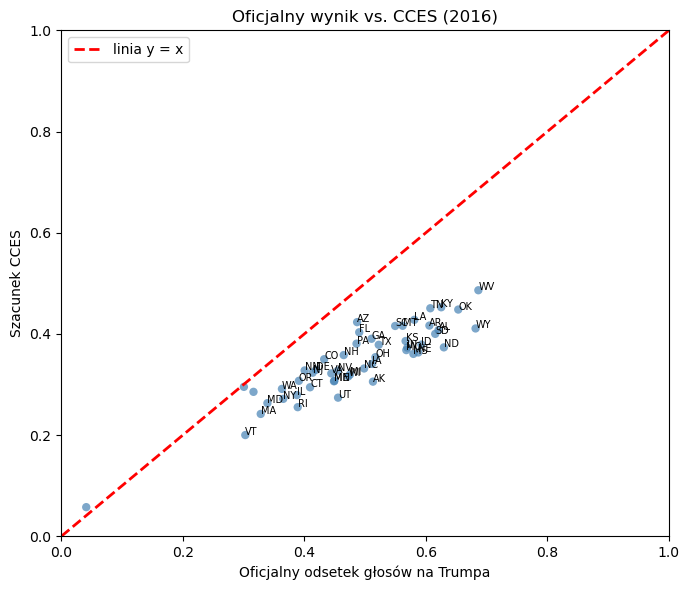

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(g2016["pct_djt_voters"], g2016["cces_pct_djt_vv"],
           c="steelblue", alpha=0.7, edgecolors="none")
ax.plot([0, 1], [0, 1], "r--", lw=2, label="linia y = x")

## etykiety stanów z dużym błędem
mask = g2016["blad"].abs() > 0.05
for _, row in g2016[mask].iterrows():
    ax.annotate(row["st"], (row["pct_djt_voters"], row["cces_pct_djt_vv"]),
                fontsize=7, ha="left")

ax.set_xlabel("Oficjalny odsetek głosów na Trumpa")
ax.set_ylabel("Szacunek CCES")
ax.set_title("Oficjalny wynik vs. CCES (2016)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Interpretacja: punkty poniżej linii $y = x$ oznaczają, że CCES **niedoszacowało** poparcie dla Trumpa w danym stanie. Większość stanów leży poniżej linii -- CCES systematycznie zaniżało poparcie dla Trumpa.

#### Błąd estymacji po stanach

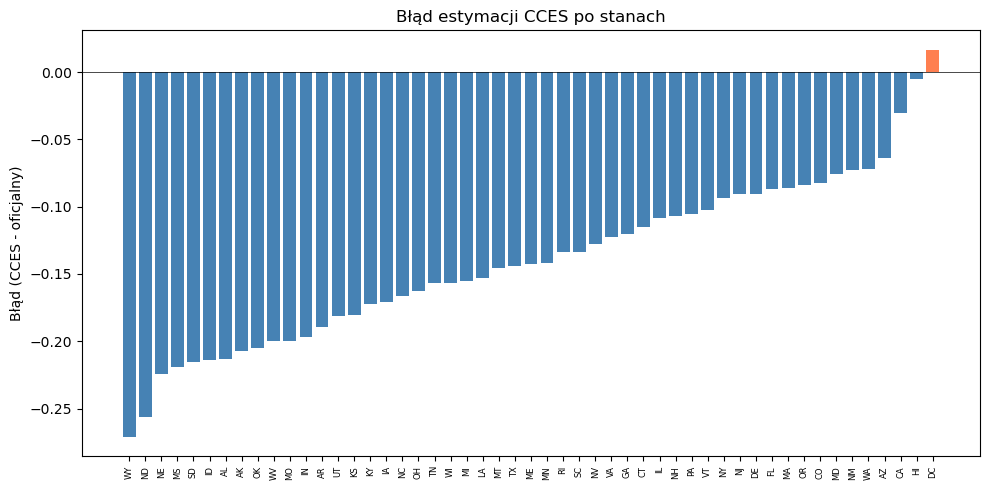

In [10]:
g_sorted = g2016.sort_values("blad")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if b < 0 else "coral" for b in g_sorted["blad"]]
ax.bar(range(len(g_sorted)), g_sorted["blad"], color=colors)
ax.set_xticks(range(len(g_sorted)))
ax.set_xticklabels(g_sorted["st"], rotation=90, fontsize=6)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Błąd (CCES - oficjalny)")
ax.set_title("Błąd estymacji CCES po stanach")
plt.tight_layout()
plt.show()

Interpretacja: niebieskie słupki (ujemne) -- CCES zaniżało poparcie Trumpa; koralowe (dodatnie) -- CCES zawyżało. Dominacja niebieskich słupków potwierdza systematyczne niedoszacowanie.

#### DDC po stanach

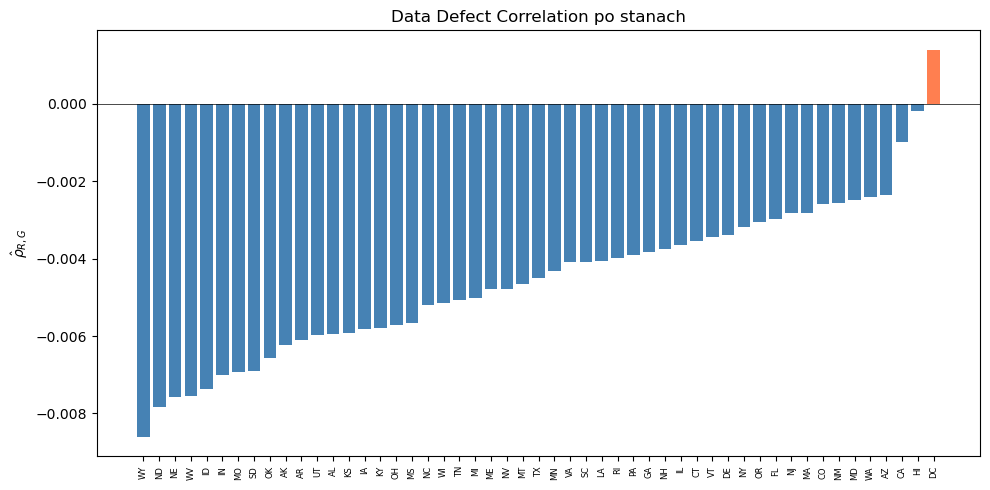

In [11]:
g_sorted2 = g2016.sort_values("ddc")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if d < 0 else "coral" for d in g_sorted2["ddc"]]
ax.bar(range(len(g_sorted2)), g_sorted2["ddc"], color=colors)
ax.set_xticks(range(len(g_sorted2)))
ax.set_xticklabels(g_sorted2["st"], rotation=90, fontsize=6)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel(r"$\hat{\rho}_{R,G}$")
ax.set_title("Data Defect Correlation po stanach")
plt.tight_layout()
plt.show()

Interpretacja: ujemne $\hat{\rho}_{R,G}$ oznacza, że wyborcy Trumpa byli niedoreprezentowani w próbie CCES. Im bardziej ujemna wartość, tym silniejsza autoselekcja w danym stanie.

#### Wielkość próby vs. błąd -- paradoks big data

Obliczmy statystykę $Z_n$ dla każdego stanu (jak u Menga, Fig. 7):

$$
Z_n = \frac{\hat{p} - p}{\sqrt{\hat{p}(1-\hat{p})/n}} = \sqrt{n} \cdot \sqrt{\frac{D_0 \rho_{R,G}^2}{1 - D_0 \rho_{R,G}^2}} \approx \sqrt{N - n} \cdot \rho_{R,G}
$$

Kluczowe przekształcenie: $\sqrt{n} \cdot \sqrt{D_0} = \sqrt{n \cdot \frac{N-n}{n}} = \sqrt{N-n}$, więc $Z_n$ zależy od wielkości **populacji** $N$, nie próby $n$. To jest **prawo wielkich populacji** Menga.

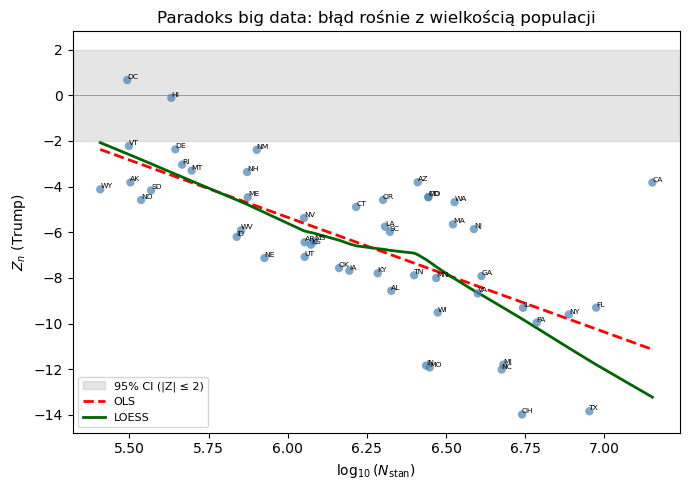

In [12]:
g2016["z_n"] = (
    (g2016["cces_pct_djt_vv"] - g2016["pct_djt_voters"]) /
    np.sqrt(g2016["cces_pct_djt_vv"] * (1 - g2016["cces_pct_djt_vv"]) / g2016["cces_n_vv"])
)

fig, ax = plt.subplots(figsize=(7, 5))

log_N = np.log10(g2016["tot_votes"])

## szary pas: 95% CI
ax.axhspan(-2, 2, color="grey", alpha=0.2, label="95% CI (|Z| ≤ 2)")
ax.scatter(log_N, g2016["z_n"], c="steelblue", alpha=0.7, edgecolors="none", zorder=3)

## etykiety stanów
for _, row in g2016.iterrows():
    ax.annotate(row["st"], (np.log10(row["tot_votes"]), row["z_n"]),
                fontsize=5.5, ha="left", va="bottom")

## OLS
slope, intercept = np.polyfit(log_N, g2016["z_n"], 1)
x_line = np.linspace(log_N.min(), log_N.max(), 100)
ax.plot(x_line, intercept + slope * x_line, "r--", lw=2, label="OLS")

## LOESS
lo = lowess(g2016["z_n"].values, log_N.values, frac=0.6)
ax.plot(lo[:, 0], lo[:, 1], color="darkgreen", lw=2, label="LOESS")

ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel(r"$\log_{10}(N_{\mathrm{stan}})$")
ax.set_ylabel(r"$Z_n$ (Trump)")
ax.set_title("Paradoks big data: błąd rośnie z wielkością populacji")
ax.legend(loc="lower left", fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.show()

Interpretacja: szary pas to konwencjonalny 95% przedział ufności ($|Z_n| \leq 2$). Większość stanów leży **poza** tym pasem, a $Z_n$ staje się coraz bardziej ujemne wraz ze wzrostem populacji stanu ($N$). To jest sedno paradoksu Menga: błąd estymacji rośnie z $\sqrt{N}$, a nie maleje z $1/\sqrt{n}$.

## Ilustracja paradoksu big data

Porównanie statystyki $Z_n$ dla próby 80% (rejestr) vs 1% (losowa) z populacji $N = 38$ mln (Polska):

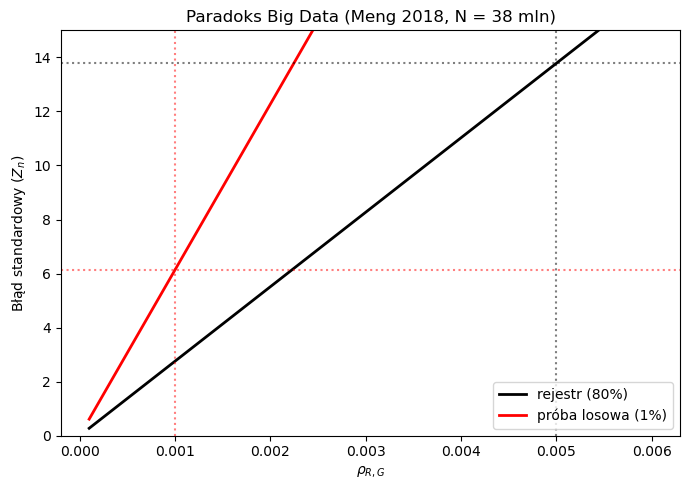

In [13]:
N = 38e6
rho_vals = np.linspace(0.0001, 0.006, 500)

def z_n_curve(rho, f_share):
    n = N * f_share
    D0 = (1 - f_share) / f_share
    return np.sqrt(n) * np.sqrt(D0 * rho**2 / (1 - D0 * rho**2))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rho_vals, z_n_curve(rho_vals, 0.8), "k-", lw=2, label="rejestr (80%)")
ax.plot(rho_vals, z_n_curve(rho_vals, 0.01), "r-", lw=2, label="próba losowa (1%)")
ax.axvline(0.001, ls=":", color="red", alpha=0.5)
ax.axhline(z_n_curve(0.001, 0.01), ls=":", color="red", alpha=0.5)
ax.axvline(0.005, ls=":", color="black", alpha=0.5)
ax.axhline(z_n_curve(0.005, 0.8), ls=":", color="black", alpha=0.5)
ax.set_xlabel(r"$\rho_{R,G}$")
ax.set_ylabel(r"Błąd standardowy ($Z_n$)")
ax.set_title("Paradoks Big Data (Meng 2018, N = 38 mln)")
ax.legend(loc="lower right", framealpha=0.8)
ax.set_ylim(0, 15)
plt.tight_layout()
plt.show()

Wniosek: mimo 80-krotnie większej próby, rejestr z autoselekcją ($\rho = 0.005$) daje błąd $Z_n \approx 14$, a próba losowa ($\rho = 0.001$) daje $Z_n \approx 6$.

# Balans zmiennych pomocniczych

## Dane: JVS vs. CBOP

Wykorzystamy dwa zbiory danych (wyeksportowane z pakietu R `nonprobsvy`):

- `jvs` -- próba losowa z Badania Popytu na Pracę (6 523 firmy) -- traktujemy jako **reprezentację populacji**,
- `admin` -- dane administracyjne z Centralnej Bazy Ofert Pracy, CBOP (9 344 firmy) -- **próba nielosowa**, w której firmy zgłaszają oferty dobrowolnie.

Pytanie: **czy CBOP jest reprezentatywne względem populacji firm?**

In [14]:
## wczytanie danych -- wyeksportowane z R:
## library(nonprobsvy); write.csv(jvs, "codes/data/jvs.csv", row.names=FALSE)
## library(nonprobsvy); write.csv(admin, "codes/data/admin.csv", row.names=FALSE)
jvs = pd.read_csv("../data/jvs.csv")
admin = pd.read_csv("../data/admin.csv")

### Opis kolumn

| Kolumna | Opis | Zbiór |
|---------|------|-------|
| `id` | Identyfikator firmy | oba |
| `private` | 1 = firma prywatna, 0 = publiczna | oba |
| `size` | Wielkość: S ($\leq 9$), M (10--49), L ($\geq 50$ pracowników) | oba |
| `nace` | Sekcja PKD (14 kategorii) | oba |
| `region` | Województwo (16 kodów: 02, 04, ..., 32) | oba |
| `weight` | Waga kalibrowana z schematu losowania | tylko JVS |
| `single_shift` | Czy firma oferuje pracę jednozmianową (0/1) | tylko CBOP |

In [15]:
print("JVS:")
display(jvs.head())
print("\nCBOP:")
display(admin.head())

JVS:


,id,private,size,nace,region,weight
0,j_1,0,L,O,14,1
1,j_2,0,L,O,24,6
2,j_3,0,L,R.S,14,1
3,j_4,0,L,R.S,14,1
4,j_5,0,L,R.S,22,1



CBOP:


,id,private,size,nace,region,single_shift
0,j_1,0,L,P,30,False
1,j_2,0,L,O,14,True
2,j_3,0,L,O,4,True
3,j_4,0,L,O,24,True
4,j_5,0,L,O,4,True


## Porównanie struktury prób

Porównajmy rozkłady zmiennych pomocniczych -- różnice wskazują na autoselekcję w CBOP. **Uwaga:** JVS jest próbą losową z wagami, więc proporcje populacyjne szacujemy z uwzględnieniem wag:

In [16]:
## ważona tablica częstości (JVS z wagami losowania)
def wprop(x, w):
    """Ważone proporcje."""
    df = pd.DataFrame({"x": x, "w": w})
    return df.groupby("x")["w"].sum() / df["w"].sum()

## rozkład wg wielkości firmy
tab_jvs = wprop(jvs["size"], jvs["weight"])
tab_admin = admin["size"].value_counts(normalize=True).sort_index()
pd.DataFrame({"JVS (ważone)": tab_jvs.round(3), "CBOP": tab_admin.round(3)})

,JVS (ważone),CBOP
L,0.165,0.272
M,0.265,0.329
S,0.570,0.399


In [17]:
## rozkład wg sektora
tab_jvs_p = wprop(jvs["private"], jvs["weight"])
tab_admin_p = admin["private"].value_counts(normalize=True).sort_index()
pd.DataFrame({"JVS (ważone)": tab_jvs_p.round(3), "CBOP": tab_admin_p.round(3)}).rename(
    index={0: "Publiczna", 1: "Prywatna"}
)

,JVS (ważone),CBOP
Publiczna,0.088,0.152
Prywatna,0.912,0.848


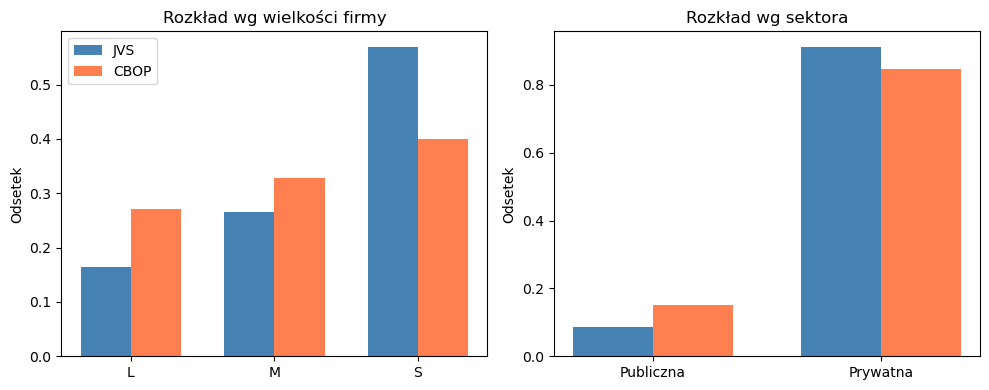

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

## wielkość firmy
x = np.arange(len(tab_jvs))
w = 0.35
axes[0].bar(x - w/2, tab_jvs.values, w, color="steelblue", label="JVS")
axes[0].bar(x + w/2, tab_admin.values, w, color="coral", label="CBOP")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tab_jvs.index)
axes[0].set_title("Rozkład wg wielkości firmy")
axes[0].set_ylabel("Odsetek")
axes[0].legend()

## sektor
x2 = np.arange(2)
axes[1].bar(x2 - w/2, tab_jvs_p.values, w, color="steelblue", label="JVS")
axes[1].bar(x2 + w/2, tab_admin_p.values, w, color="coral", label="CBOP")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(["Publiczna", "Prywatna"])
axes[1].set_title("Rozkład wg sektora")
axes[1].set_ylabel("Odsetek")

plt.tight_layout()
plt.show()

Interpretacja: CBOP **nadreprezentuje firmy publiczne i duże** -- to typowe dla rejestrów administracyjnych, gdzie urzędy mają obowiązek zgłaszania ofert, a firmy prywatne (zwłaszcza małe) robią to dobrowolnie.

## Standaryzowana różnica średnich (SMD)

$$
\text{SMD} = \frac{\bar{x}_{\text{CBOP}} - \bar{x}_{\text{JVS}}^w}{\sqrt{(s^2_{\text{CBOP}} + s^{2,w}_{\text{JVS}})/2}}
$$

gdzie $\bar{x}^w$ i $s^{2,w}$ oznaczają ważoną średnią i wariancję (z wagami losowania JVS).

Przyjmuje się, że $|\text{SMD}| < 0.1$ oznacza akceptowalny balans, a $|\text{SMD}| > 0.25$ to poważny brak balansu.

In [19]:
def smd_weighted(x_treat, x_ctrl, w_ctrl):
    """SMD z ważoną grupą kontrolną (JVS)."""
    mean_t = x_treat.mean()
    var_t = x_treat.var()
    mean_c = np.average(x_ctrl, weights=w_ctrl)
    var_c = np.average((x_ctrl - mean_c)**2, weights=w_ctrl)
    return (mean_t - mean_c) / np.sqrt((var_t + var_c) / 2)

## przygotowanie dummy variables
wspol = ["private", "size", "nace", "region"]

jvs_dum = pd.get_dummies(jvs[wspol], columns=["size", "nace", "region"], dtype=float)
admin_dum = pd.get_dummies(admin[wspol], columns=["size", "nace", "region"], dtype=float)

## zapewnij te same kolumny
all_cols = sorted(set(jvs_dum.columns) | set(admin_dum.columns))
jvs_dum = jvs_dum.reindex(columns=all_cols, fill_value=0)
admin_dum = admin_dum.reindex(columns=all_cols, fill_value=0)

## wagi JVS
w_jvs = jvs["weight"].values

## oblicz SMD (ważone dla JVS)
smd_vals = {col: smd_weighted(admin_dum[col], jvs_dum[col], w_jvs) for col in all_cols}
smd_df = pd.DataFrame({"SMD": smd_vals}).sort_values("SMD", key=abs, ascending=False)
smd_df.round(4).head(15)

,SMD
size_S,-0.3461
size_L,0.2611
region_14,-0.2490
nace_P,0.2041
private,-0.1989
region_4,0.1723
region_18,0.1708
nace_F,-0.1449
size_M,0.1391
nace_G,-0.1378


## Ważenie propensity score

Estymujemy propensity score, czyli $P(\text{CBOP} \mid \mathbf{X})$ -- prawdopodobieństwo, że firma znajdzie się w CBOP, a nie w JVS. Odwrotności tych prawdopodobieństw stają się wagami korygującymi:

In [25]:
## łączymy zbiory (zachowując wagi JVS)
jvs_sub = jvs[wspol].copy()
jvs_sub["source"] = 0
jvs_sub["weight"] = jvs["weight"].values
admin_sub = admin[wspol].copy()
admin_sub["source"] = 1
admin_sub["weight"] = 1.0  ## CBOP: waga = 1

combined = pd.concat([jvs_sub, admin_sub], ignore_index=True)
combined_dum = pd.get_dummies(combined[wspol], columns=["size", "nace", "region"], dtype=float)

## regresja logistyczna z wagami (GLM obsługuje freq_weights)
X = sm.add_constant(combined_dum)
y = combined["source"]
ps_model = sm.GLM(y, X, family=sm.families.Binomial(),
                  freq_weights=combined["weight"]).fit()
ps_hat = ps_model.predict(X)

print(f"JVS: {(y == 0).sum()} firm")
print(f"CBOP: {(y == 1).sum()} firm")

JVS: 6523 firm
CBOP: 9344 firm


## Balans po ważeniu

In [26]:
## wagi IPW dla JVS (reweight JVS to look like CBOP)
ps_jvs = ps_hat[y == 0].values
ipw_weights = ps_jvs / (1 - ps_jvs)
## wagi końcowe = wagi losowania * wagi IPW
final_weights = w_jvs * ipw_weights

## SMD po ważeniu
smd_adj = {}
for col in all_cols:
    weighted_mean = np.average(jvs_dum[col], weights=final_weights)
    weighted_var = np.average((jvs_dum[col] - weighted_mean)**2, weights=final_weights)
    admin_mean = admin_dum[col].mean()
    admin_var = admin_dum[col].var()
    pooled_sd = np.sqrt((admin_var + weighted_var) / 2)
    smd_adj[col] = (admin_mean - weighted_mean) / pooled_sd if pooled_sd > 0 else 0

## porównanie
balance = pd.DataFrame({
    "SMD_unadj": smd_df["SMD"],
    "SMD_adj": pd.Series(smd_adj)
}).sort_values("SMD_unadj", key=abs, ascending=False)
balance.round(4).head(15)

,SMD_unadj,SMD_adj
size_S,-0.3461,-0.0052
size_L,0.2611,0.0034
region_14,-0.2490,0.0026
nace_P,0.2041,0.0028
private,-0.1989,0.0053
region_4,0.1723,-0.0125
region_18,0.1708,-0.0014
nace_F,-0.1449,0.0028
size_M,0.1391,0.0022
nace_G,-0.1378,0.0061


## Wykres Love'a

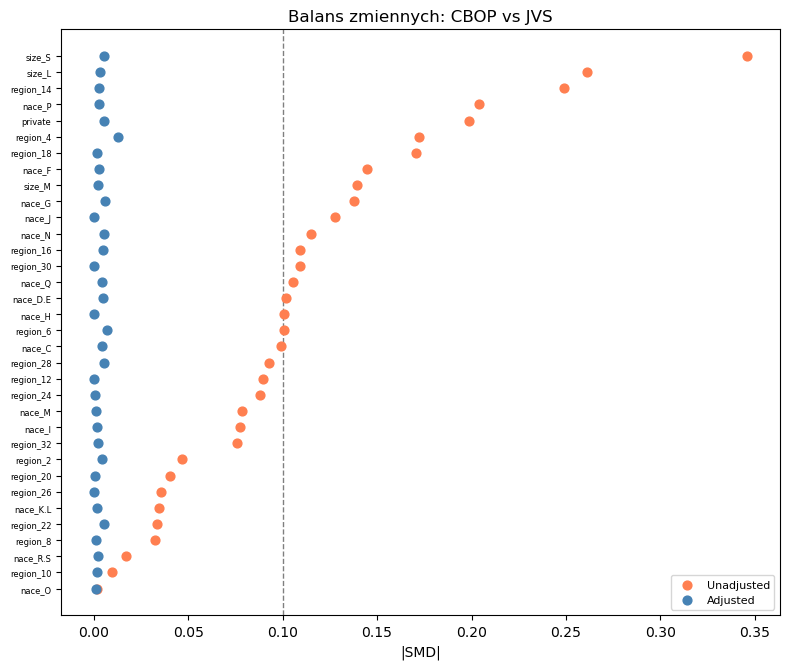

In [27]:
## sortuj wg |SMD| przed ważeniem
balance_sorted = balance.sort_values("SMD_unadj", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(balance_sorted) * 0.2)))
y_pos = np.arange(len(balance_sorted))

ax.scatter(balance_sorted["SMD_unadj"].abs(), y_pos, c="coral", s=40, zorder=3, label="Unadjusted")
ax.scatter(balance_sorted["SMD_adj"].abs(), y_pos, c="steelblue", s=40, zorder=3, label="Adjusted")
ax.axvline(0.1, ls="--", color="black", lw=1, alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(balance_sorted.index, fontsize=6)
ax.set_xlabel("|SMD|")
ax.set_title("Balans zmiennych: CBOP vs JVS")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Interpretacja:

- **Pomarańczowe punkty (Unadjusted)** -- SMD przed ważeniem. Zmienne po prawej stronie progu 0.1 wskazują na istotne różnice między CBOP a JVS.
- **Niebieskie punkty (Adjusted)** -- SMD po zastosowaniu wag. Powinny przesunąć się w lewo, poniżej progu 0.1.
- Zmienne, które po ważeniu nadal przekraczają próg, wskazują na utrzymujący się brak balansu.

# R-indicator (Schouten i in. 2009)

## Definicja

R-indicator to syntetyczna miara reprezentatywności oparta na zmienności propensity scores:

$$
R = 1 - 2 \cdot S(\hat{\pi}_i),
$$

gdzie $S(\hat{\pi}_i)$ to odchylenie standardowe oszacowanych prawdopodobieństw włączenia do próby.

- $R = 1$: pełna reprezentatywność (brak autoselekcji).
- $R \to 0$: silna autoselekcja.

In [23]:
R_indicator = 1 - 2 * ps_hat.std()
print(f"R-indicator: {R_indicator:.4f}")
print(f"SD propensity scores: {ps_hat.std():.4f}")

R-indicator: 0.4903
SD propensity scores: 0.2549


Interpretacja: $R$ znacząco mniejsze od 1 potwierdza, że CBOP **nie jest reprezentatywne** -- prawdopodobieństwo pojawienia się firmy w CBOP silnie zależy od jej cech.

## Rozkład propensity scores

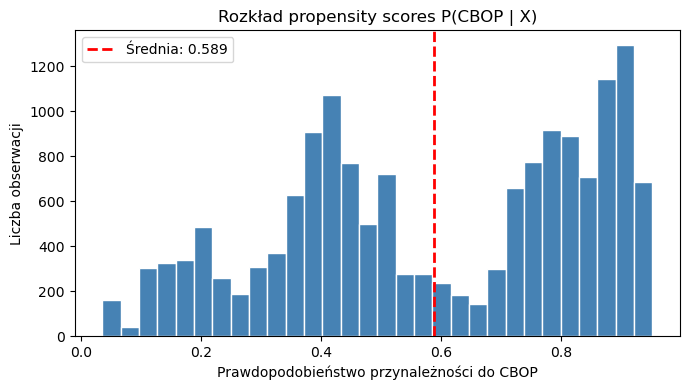

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ps_hat, bins=30, color="steelblue", edgecolor="white")
ax.axvline(ps_hat.mean(), ls="--", color="red", lw=2, label=f"Średnia: {ps_hat.mean():.3f}")
ax.set_xlabel("Prawdopodobieństwo przynależności do CBOP")
ax.set_ylabel("Liczba obserwacji")
ax.set_title("Rozkład propensity scores P(CBOP | X)")
ax.legend(framealpha=0.8)
plt.tight_layout()
plt.show()

Interpretacja: gdyby CBOP było reprezentatywne, rozkład propensity scores byłby skupiony wokół jednej wartości (wąski pik). Szeroki, wielomodalny rozkład oznacza, że firmy o różnych cechach mają drastycznie różne szanse pojawienia się w CBOP.

# Podsumowanie

| Miara | Co mierzy | Wartość referencyjna | Implementacja |
|-------|-----------|---------------------|---------------|
| DDC ($\rho_{R,G}$) | Korelacja między selekcją a cechą badaną | 0 (brak obciążenia) | `ddc()` (własna) |
| DDI ($\rho_{R,G}^2$) | Kwadrat DDC (indeks defektu danych) | 0 | `ddc()**2` |
| R-indicator | Zmienność propensity scores | 1 (pełna reprezentatywność) | `1 - 2*std(ps)` |
| SMD | Standaryzowana różnica średnich | $< 0.1$ (dobry balans) | `smd()` (własna) |

Kluczowa różnica:

- **DDC/DDI** -- wymaga znajomości prawdziwej wartości parametru w populacji ($\mu$); mierzy efekt autoselekcji na **konkretną** zmienną badaną.
- **R-indicator / SMD** -- **nie** wymaga znajomości $\mu$; mierzy ogólną (nie)reprezentatywność próby na podstawie zmiennych pomocniczych $\mathbf{X}$.

# Odniesienia

- Meng, X.-L. (2018). Statistical Paradises and Paradoxes in Big Data (I). *Annals of Applied Statistics*, 12(2), 685--726.
- Bradley, V.C. i in. (2021). Unrepresentative big surveys significantly overestimated US vaccine uptake. *Nature*, 600, 695--700.
- Schouten, B., Cobben, F. i Bethlehem, J. (2009). Indicators for the representativeness of survey response. *Survey Methodology*, 35(1), 101--113.
- Shlomo, N. i Kim, M.S. (2025). Quality indicators for representation in administrative data. *Survey Methodology*, 51(2), 509--532.